# HealthSense AI — V6 Research Freeze Visual Review

## Mục tiêu

Notebook này là **visual review chính cho V6 research freeze**.

Nó không re-implement experiment logic. Nó đọc artifact do các scripts `experiments/08_v6_locked_protocol/*.py` sinh ra, và chỉ chạy lại scripts khi bạn chủ động bật flag.

Notebook tập trung vào:

- frozen V6C stacking;
- reused subject-held-out window metrics;
- Global Rule V2;
- calibration;
- confidence intervals;
- LODO domain generalization;
- PPG_AC ablation;
- PAC/PVC challenge;
- DeepBeat failure-mode forensic;
- freeze/provenance/checksum.

> Các reused test không được gọi là pristine external validation.

In [1]:
from pathlib import Path
import sys
import json
import subprocess
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
)

warnings.filterwarnings("ignore", category=UserWarning)

def find_repo_root():
    candidates = [
        Path.cwd(),
        Path("/home/phuc/Documents/HealthSense_rungtamnhi"),
        Path.cwd().parent,
    ]
    for p in candidates:
        if (p / "src/healthsense_ml").exists():
            return p.resolve()
    raise FileNotFoundError(
        "Không tìm thấy HealthSense repo. "
        "Hãy cd vào /home/phuc/Documents/HealthSense_rungtamnhi "
        "hoặc sửa REPO thủ công."
    )

REPO = find_repo_root()
print("REPO =", REPO)

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

REPO = /home/phuc/Documents/HealthSense_rungtamnhi


In [2]:
def run_script(relative_path, *args, check=True):
    script = REPO / relative_path
    if not script.exists():
        raise FileNotFoundError(script)
    cmd = [sys.executable, str(script), *map(str, args)]
    print(">", " ".join(cmd))
    return subprocess.run(cmd, cwd=REPO, check=check)

def first_existing(paths):
    for p in paths:
        p = REPO / p
        if p.exists():
            return p
    return None

def infer_binary_columns(df):
    label_candidates = [
        "label", "label_eval", "binary_label_clean", "binary_label",
        "label_v7", "y_true", "gt"
    ]
    prob_candidates = [
        "meta_probability", "stack_probability", "probability",
        "af_probability", "prob_af", "y_prob", "pred_proba"
    ]
    label_col = next((c for c in label_candidates if c in df.columns), None)
    prob_col = next((c for c in prob_candidates if c in df.columns), None)
    return label_col, prob_col

def binary_metrics(y, p, threshold=0.5):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "AUROC": roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan,
        "PR_AUC": average_precision_score(y, p) if np.any(y == 1) else np.nan,
        "Brier": brier_score_loss(y, p),
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "Sensitivity": tp / (tp + fn) if tp + fn else np.nan,
        "Specificity": tn / (tn + fp) if tn + fp else np.nan,
    }

def plot_roc_pr(df, label_col, prob_col, title):
    y = df[label_col].astype(int).to_numpy()
    p = df[prob_col].astype(float).to_numpy()

    fig = plt.figure(figsize=(7, 5))
    fpr, tpr, _ = roc_curve(y, p)
    plt.plot(fpr, tpr, label=f"AUROC={roc_auc_score(y,p):.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"{title} — ROC")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    fig = plt.figure(figsize=(7, 5))
    precision, recall, _ = precision_recall_curve(y, p)
    plt.plot(recall, precision, label=f"PR-AUC={average_precision_score(y,p):.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} — Precision–Recall")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

def plot_probability_distribution(df, label_col, prob_col, title):
    fig = plt.figure(figsize=(8, 5))
    for label in sorted(df[label_col].dropna().unique()):
        vals = df.loc[df[label_col] == label, prob_col].astype(float)
        plt.hist(vals, bins=35, alpha=0.45, density=True, label=f"label={label}")
    plt.xlabel("AF probability")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

def plot_confusion(y, pred, title):
    cm = confusion_matrix(y, pred, labels=[0,1])
    fig = plt.figure(figsize=(5.5, 5))
    plt.imshow(cm)
    plt.xticks([0,1], ["Pred 0", "Pred 1"])
    plt.yticks([0,1], ["True 0", "True 1"])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.title(title)
    plt.xlabel("Prediction")
    plt.ylabel("Ground truth")
    plt.colorbar()
    plt.show()

## 1. Research freeze status

In [3]:
ART = REPO / "experiments/08_v6_locked_protocol/artifacts"

freeze_json = ART / "V6_RESEARCH_FREEZE_STATUS.json"
if freeze_json.exists():
    freeze_status = json.loads(freeze_json.read_text())
    print(json.dumps(freeze_status, indent=2))
else:
    print("Chưa có V6_RESEARCH_FREEZE_STATUS.json")

{
  "project": "HealthSense AF PPG Screening",
  "freeze_version": "V6_RESEARCH_FREEZE_2026_09",
  "primary_model": "models/multidomain/healthsense_af_v6c_stacking.pkl",
  "feature_schema": {
    "n_features": 14,
    "features": [
      "HR_mean",
      "Mean_NN",
      "SDNN",
      "RMSSD",
      "NN50",
      "pNN50",
      "CV",
      "HF",
      "Total_Power",
      "HF_norm",
      "SD1",
      "SD2",
      "SampEn",
      "PPG_AC"
    ],
    "PPG_AC": "RETAIN"
  },
  "probability_output": {
    "primary": "raw meta_probability",
    "platt_calibration": "ANALYSIS_ONLY_NOT_PROMOTED",
    "reason": "Platt calibration did not improve development performance consistently across domains."
  },
  "subject_alert_rule": {
    "candidate": {
      "version": "v6_locked_global_rule_v2",
      "decision": "(base persistent episode) OR (high-confidence short episode)",
      "base": {
        "probability_threshold": 0.8,
        "uncertainty_threshold": 0.05,
        "min_consecutive": 5


## 2. Frozen V6C stacking bundle

In [4]:
V6_MODEL = REPO / "models/multidomain/healthsense_af_v6c_stacking.pkl"
assert V6_MODEL.exists(), V6_MODEL

bundle = joblib.load(V6_MODEL)

print("keys:", bundle.keys())
print("\nfeatures:")
print(bundle["features"])
print("\nbase models:", list(bundle["base_models"].keys()))
print("\nmeta:", bundle["meta"])
print("\nsize:", V6_MODEL.stat().st_size / 1024 / 1024 / 1024, "GiB")

keys: dict_keys(['base_models', 'meta', 'features'])

features:
['HR_mean', 'Mean_NN', 'SDNN', 'RMSSD', 'NN50', 'pNN50', 'CV', 'HF', 'Total_Power', 'HF_norm', 'SD1', 'SD2', 'SampEn', 'PPG_AC']

base models: ['ExtraTrees', 'RandomForest', 'XGBoost']

meta: Pipeline(steps=[('scale', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000))])

size: 1.7480880348011851 GiB


## 3. Optional: run exact locked protocol scripts

In [5]:
LOCKED_SCRIPTS = [
    "experiments/08_v6_locked_protocol/01_generate_locked_predictions.py",
    "experiments/08_v6_locked_protocol/02_audit_temporal_and_splits.py",
    "experiments/08_v6_locked_protocol/03_build_verified_streams.py",
    "experiments/08_v6_locked_protocol/06_tune_global_rule_v2_dev.py",
    "experiments/08_v6_locked_protocol/07_evaluate_global_rule_v2_test.py",
    "experiments/08_v6_locked_protocol/08_calibration_diagnostics.py",
    "experiments/08_v6_locked_protocol/09_subject_cluster_bootstrap.py",
    "experiments/08_v6_locked_protocol/10_exact_subject_ci.py",
    "experiments/08_v6_locked_protocol/12_collect_lodo_results.py",
    "experiments/08_v6_locked_protocol/13_ppg_ac_ablation_dev.py",
    "experiments/08_v6_locked_protocol/14_pac_pvc_challenge.py",
    "experiments/08_v6_locked_protocol/15_deepbeat_lodo_forensics.py",
    "experiments/08_v6_locked_protocol/16_deepbeat_domain_exposure.py",
    "experiments/08_v6_locked_protocol/17_deepbeat_lodo_ppg_ac_ablation.py",
    "experiments/08_v6_locked_protocol/18_finalize_v6_research_freeze.py",
]

for s in LOCKED_SCRIPTS:
    print(("OK  " if (REPO/s).exists() else "MISS"), s)

RUN_LOCKED_REPRO = False

if RUN_LOCKED_REPRO:
    # CẢNH BÁO: một số bước có thể tốn thời gian và ghi lại artifact.
    for s in LOCKED_SCRIPTS:
        if (REPO/s).exists():
            run_script(s)

OK   experiments/08_v6_locked_protocol/01_generate_locked_predictions.py
OK   experiments/08_v6_locked_protocol/02_audit_temporal_and_splits.py
OK   experiments/08_v6_locked_protocol/03_build_verified_streams.py
OK   experiments/08_v6_locked_protocol/06_tune_global_rule_v2_dev.py
OK   experiments/08_v6_locked_protocol/07_evaluate_global_rule_v2_test.py
OK   experiments/08_v6_locked_protocol/08_calibration_diagnostics.py
OK   experiments/08_v6_locked_protocol/09_subject_cluster_bootstrap.py
OK   experiments/08_v6_locked_protocol/10_exact_subject_ci.py
OK   experiments/08_v6_locked_protocol/12_collect_lodo_results.py
OK   experiments/08_v6_locked_protocol/13_ppg_ac_ablation_dev.py
OK   experiments/08_v6_locked_protocol/14_pac_pvc_challenge.py
OK   experiments/08_v6_locked_protocol/15_deepbeat_lodo_forensics.py
OK   experiments/08_v6_locked_protocol/16_deepbeat_domain_exposure.py
OK   experiments/08_v6_locked_protocol/17_deepbeat_lodo_ppg_ac_ablation.py
OK   experiments/08_v6_locked_proto

## 4. Reused subject-held-out window metrics

DeepBeat -> label meta_probability 1363


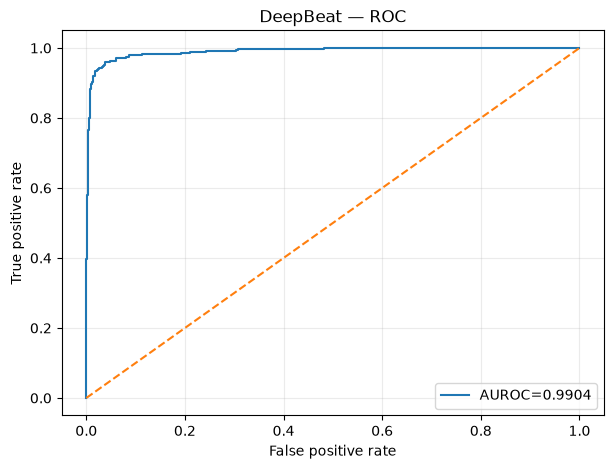

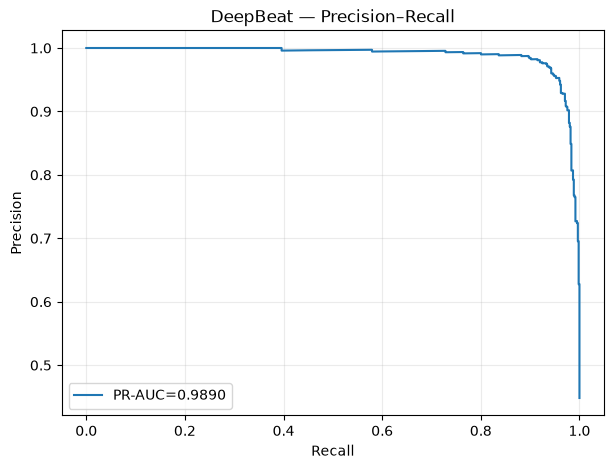

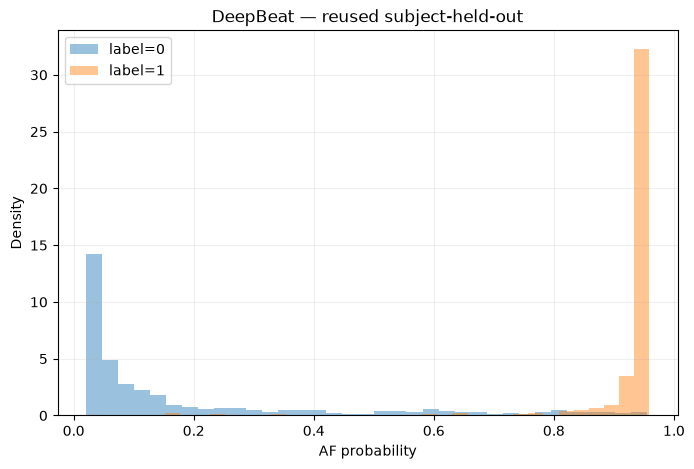

PulseWatch -> label meta_probability 30158


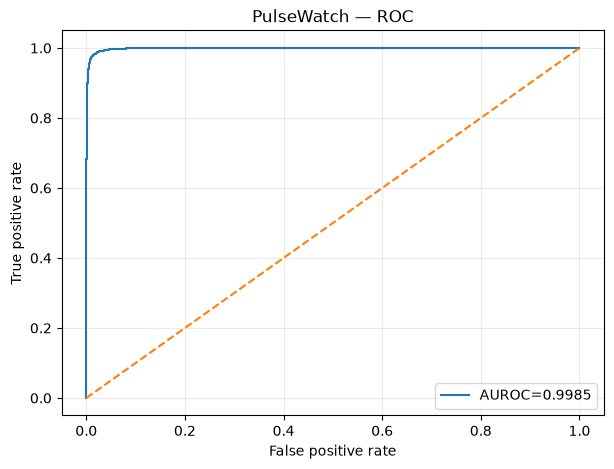

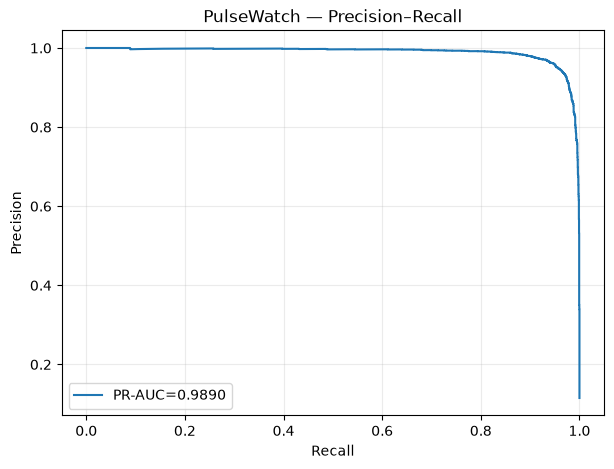

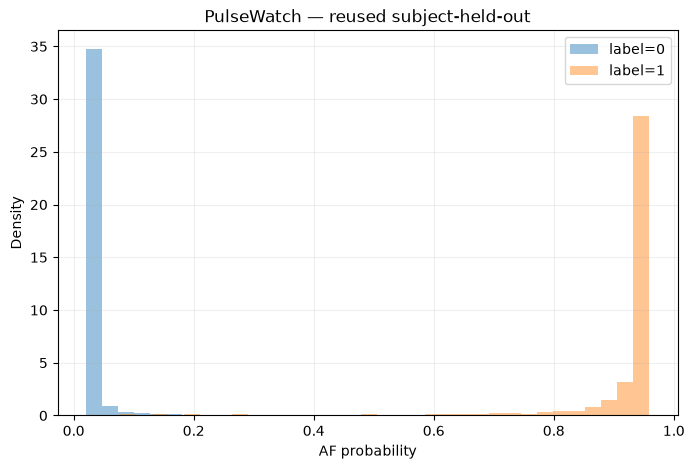

Liu -> label meta_probability 920


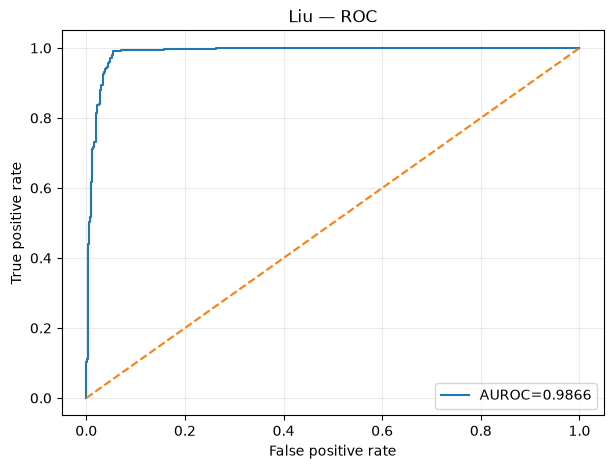

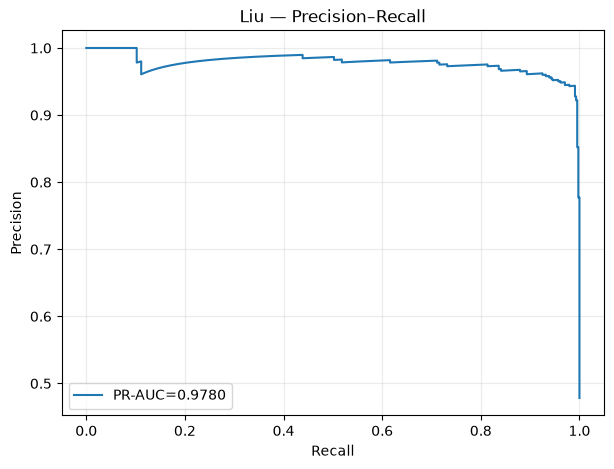

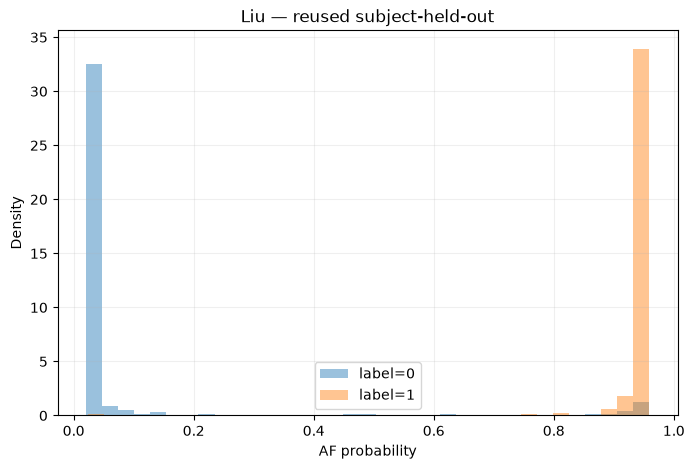

,dataset,n,AUROC,PR_AUC,Brier,TP,TN,FP,FN,Sensitivity,Specificity
0,DeepBeat,1363,0.990391,0.988966,0.058315,600,645,107,11,0.981997,0.857713
1,PulseWatch,30158,0.998465,0.988954,0.009483,3362,26457,229,110,0.968318,0.991419
2,Liu,920,0.986624,0.977976,0.032217,436,450,30,4,0.990909,0.937500


In [6]:
locked_files = {
    "DeepBeat": ART / "deepbeat_test_locked_predictions.csv",
    "PulseWatch": ART / "pulsewatch_test_locked_predictions.csv",
    "Liu": ART / "liu_test_locked_predictions.csv",
}

rows = []
for name, path in locked_files.items():
    if not path.exists():
        print("MISS", path)
        continue

    df = pd.read_csv(path, low_memory=False)
    label_col, prob_col = infer_binary_columns(df)
    print(name, "->", label_col, prob_col, len(df))

    if label_col and prob_col:
        d = df[[label_col, prob_col]].dropna()
        m = binary_metrics(d[label_col], d[prob_col])
        rows.append({"dataset": name, "n": len(d), **m})

        plot_roc_pr(d, label_col, prob_col, name)
        plot_probability_distribution(d, label_col, prob_col, f"{name} — reused subject-held-out")

window_summary = pd.DataFrame(rows)
display(window_summary)

### Cross-domain discrimination

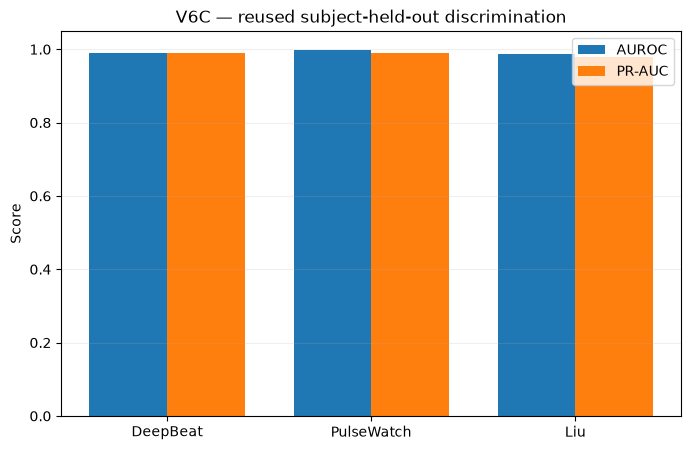

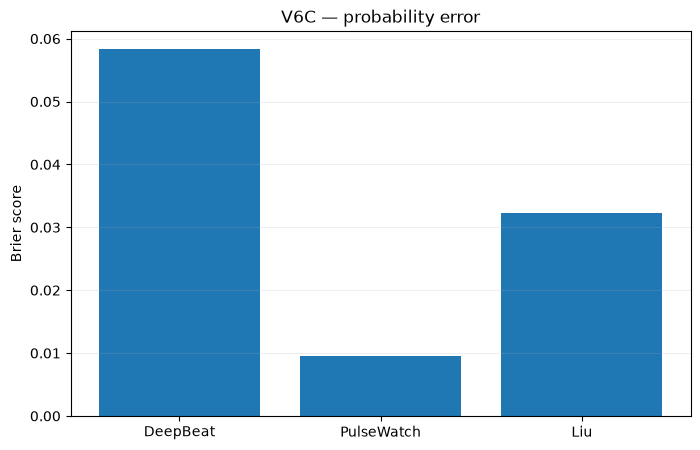

In [7]:
if "window_summary" in globals() and not window_summary.empty:
    x = np.arange(len(window_summary))
    width = 0.38

    fig = plt.figure(figsize=(8, 5))
    plt.bar(x-width/2, window_summary["AUROC"], width, label="AUROC")
    plt.bar(x+width/2, window_summary["PR_AUC"], width, label="PR-AUC")
    plt.xticks(x, window_summary["dataset"])
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title("V6C — reused subject-held-out discrimination")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()

    fig = plt.figure(figsize=(8, 5))
    plt.bar(window_summary["dataset"], window_summary["Brier"])
    plt.ylabel("Brier score")
    plt.title("V6C — probability error")
    plt.grid(axis="y", alpha=0.2)
    plt.show()

## 5. Verified temporal streams

,dataset,split,rows,subjects,streams,median_stream_windows,p95_stream_windows,max_stream_windows,rows_in_stream_ge_2,rows_in_stream_ge_3,rows_in_stream_ge_5
0,deepbeat,dev,4026,13,1011,2.0,13.50,70,0.889717,0.795827,0.646051
1,deepbeat,test,1363,7,376,1.0,19.25,39,0.851798,0.768158,0.625825
2,pulsewatch,dev,17679,16,4796,2.0,10.00,20,0.896261,0.807229,0.666101
3,pulsewatch,test,30158,16,7804,2.0,9.00,23,0.907520,0.824292,0.688772
4,liu,dev,997,7,306,2.0,11.00,69,0.868606,0.708124,0.526580
5,liu,test,920,7,147,2.0,24.40,165,0.929348,0.857609,0.772826


numeric columns: ['rows', 'subjects', 'streams', 'median_stream_windows', 'p95_stream_windows', 'max_stream_windows', 'rows_in_stream_ge_2', 'rows_in_stream_ge_3', 'rows_in_stream_ge_5']


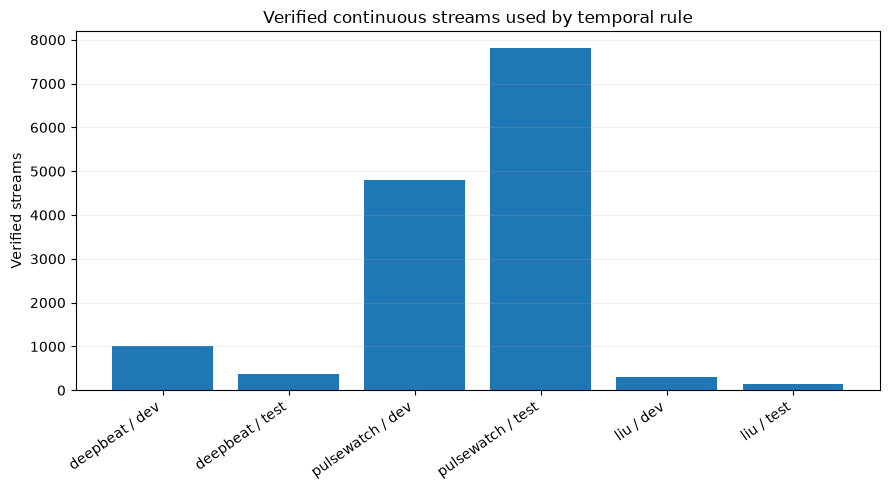

In [8]:
stream_summary_file = ART / "verified_stream_summary.csv"

if stream_summary_file.exists():
    streams = pd.read_csv(stream_summary_file)
    display(streams)

    numeric_candidates = [c for c in streams.columns if pd.api.types.is_numeric_dtype(streams[c])]
    print("numeric columns:", numeric_candidates)

    # A generic stream-count plot if standard names exist.
    count_col = next((c for c in ["streams", "n_streams", "stream_count"] if c in streams.columns), None)
    dataset_col = next((c for c in ["dataset", "domain"] if c in streams.columns), None)
    split_col = next((c for c in ["split"] if c in streams.columns), None)

    if count_col and dataset_col:
        labels = streams[dataset_col].astype(str)
        if split_col:
            labels = labels + " / " + streams[split_col].astype(str)

        fig = plt.figure(figsize=(9, 5))
        plt.bar(labels, streams[count_col])
        plt.xticks(rotation=35, ha="right")
        plt.ylabel("Verified streams")
        plt.title("Verified continuous streams used by temporal rule")
        plt.grid(axis="y", alpha=0.2)
        plt.tight_layout()
        plt.show()
else:
    print("verified_stream_summary.csv chưa có.")

## 6. Global Rule V2

In [9]:
rule_file = ART / "FROZEN_GLOBAL_RULE_V2.json"

if rule_file.exists():
    rule = json.loads(rule_file.read_text())
    print(json.dumps(rule, indent=2))
else:
    rule = None
    print("Missing", rule_file)

{
  "version": "v6_locked_global_rule_v2",
  "decision": "(base persistent episode) OR (high-confidence short episode)",
  "base": {
    "probability_threshold": 0.8,
    "uncertainty_threshold": 0.05,
    "min_consecutive": 5
  },
  "rescue": {
    "probability_threshold": 0.9,
    "uncertainty_threshold": 0.05,
    "min_consecutive": 2
  },
  "stream_policy": "consecutive windows must belong to the same verified stream; gaps reset persistence",
  "selection_data": "DEV_ONLY",
  "test_used_numerically_for_selection": false,
  "important_protocol_note": "The reused test sets had already been inspected before V2 rule design. Therefore V2 remains exploratory and requires confirmation on a future untouched external dataset.",
  "constraints": {
    "macro_sensitivity_min": 0.85,
    "per_dataset_sensitivity_min": 0.75
  },
  "development_metrics": {
    "macro_sensitivity": 0.8611111111111112,
    "macro_specificity": 0.8962962962962964,
    "macro_balanced_accuracy": 0.8787037037037037,


,TP,TN,FP,FN,sensitivity,specificity,PPV,NPV,accuracy,F1,balanced_accuracy,dataset,evaluation,base_probability,base_uncertainty,base_run,rescue_probability,rescue_uncertainty,rescue_run
0,5,2,0,0,1.0,1.0,1.0,1.0,1.000000,1.0,1.00,deepbeat,REUSED_TEST_EXPLORATORY,0.8,0.05,5,0.9,0.05,2
1,4,12,0,0,1.0,1.0,1.0,1.0,1.000000,1.0,1.00,pulsewatch,REUSED_TEST_EXPLORATORY,0.8,0.05,5,0.9,0.05,2
2,4,1,1,1,0.8,0.5,0.8,0.5,0.714286,0.8,0.65,liu,REUSED_TEST_EXPLORATORY,0.8,0.05,5,0.9,0.05,2


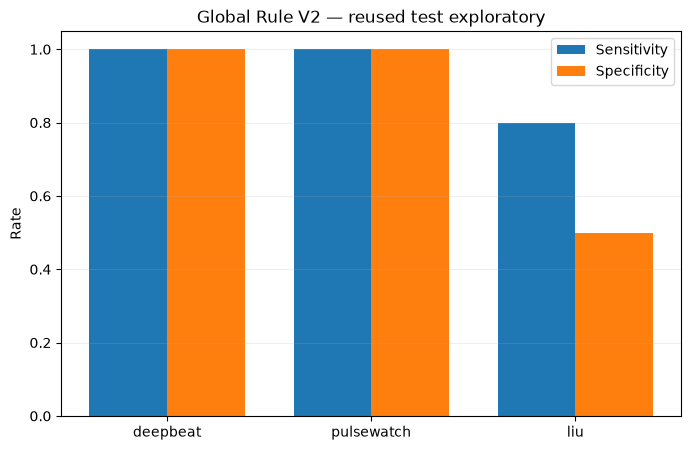

In [10]:
v2_dev_file = ART / "dev_global_rule_v2_grid.csv"
v2_test_file = ART / "global_rule_v2_reused_test_summary.csv"

if v2_test_file.exists():
    v2_test = pd.read_csv(v2_test_file)
    display(v2_test)

    fig = plt.figure(figsize=(8, 5))
    x = np.arange(len(v2_test))
    width = 0.38
    plt.bar(x-width/2, v2_test["sensitivity"], width, label="Sensitivity")
    plt.bar(x+width/2, v2_test["specificity"], width, label="Specificity")
    plt.xticks(x, v2_test["dataset"])
    plt.ylim(0, 1.05)
    plt.ylabel("Rate")
    plt.title("Global Rule V2 — reused test exploratory")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()

## 7. Calibration: RAW vs DEV-fitted Platt

,dataset,split,method,rows,subjects,AUROC,PR_AUC,Brier,LogLoss,ECE_fixed_10,ECE_quantile_10,calibration_intercept,calibration_slope
0,deepbeat,DEV,RAW,4026,13,0.807879,0.433456,0.112268,0.367042,0.080047,0.092353,-1.105744,0.544804
1,deepbeat,DEV,PLATT_OOF,4026,13,0.627654,0.325826,0.121428,0.438564,0.107125,0.107237,-1.248380,0.370492
2,pulsewatch,DEV,RAW,17679,16,0.990505,0.939022,0.028812,0.109271,0.033858,0.033858,-1.072370,1.204917
3,pulsewatch,DEV,PLATT_OOF,17679,16,0.981547,0.903578,0.030398,0.114560,0.025476,0.025476,-0.718718,1.146798
4,liu,DEV,RAW,997,7,0.981372,0.667731,0.043037,0.152525,0.069459,0.068025,-2.580293,1.094585
5,liu,DEV,PLATT_OOF,997,7,0.975795,0.604364,0.043195,0.151673,0.066204,0.066204,-2.274516,1.036573
6,POOLED,DEV,RAW,22702,36,0.975378,0.871768,0.044237,0.156884,0.039251,0.041708,-0.957437,0.996844
7,POOLED,DEV,PLATT_OOF,22702,36,0.937453,0.809404,0.047103,0.173649,0.030767,0.034746,-0.743844,0.923736
8,deepbeat,REUSED_TEST,RAW,1363,7,0.990391,0.988966,0.058315,0.203830,0.097791,0.101095,-2.314816,1.888811
9,deepbeat,REUSED_TEST,PLATT_DEV_FROZEN,1363,7,0.990391,0.988966,0.051118,0.188795,0.090475,0.094038,-1.724141,1.953370


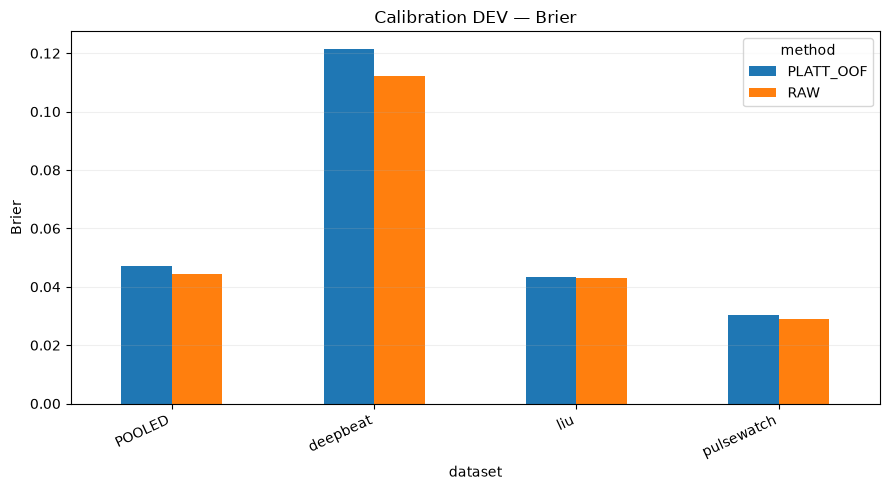

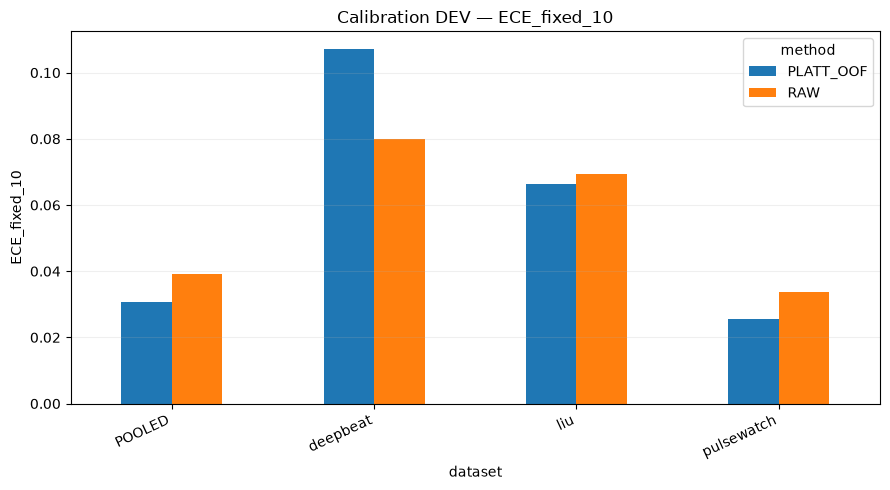

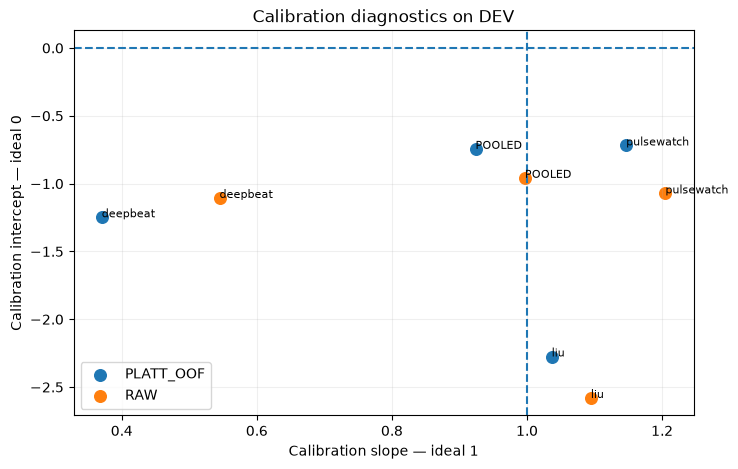

In [11]:
cal_file = ART / "calibration_summary.csv"

if cal_file.exists():
    cal = pd.read_csv(cal_file)
    display(cal)

    for metric in ["Brier", "ECE_fixed_10"]:
        subset = cal[cal["split"] == "DEV"].copy()
        if subset.empty:
            continue

        pivot = subset.pivot(index="dataset", columns="method", values=metric)
        fig = plt.figure(figsize=(9, 5))
        pivot.plot(kind="bar", ax=plt.gca())
        plt.ylabel(metric)
        plt.title(f"Calibration DEV — {metric}")
        plt.xticks(rotation=25, ha="right")
        plt.grid(axis="y", alpha=0.2)
        plt.tight_layout()
        plt.show()

    # Slope/intercept diagnostics
    dev = cal[cal["split"] == "DEV"]
    if not dev.empty:
        fig = plt.figure(figsize=(8, 5))
        for method, g in dev.groupby("method"):
            plt.scatter(g["calibration_slope"], g["calibration_intercept"], label=method, s=70)
            for _, r in g.iterrows():
                plt.text(r["calibration_slope"], r["calibration_intercept"], r["dataset"], fontsize=8)
        plt.axvline(1, linestyle="--")
        plt.axhline(0, linestyle="--")
        plt.xlabel("Calibration slope — ideal 1")
        plt.ylabel("Calibration intercept — ideal 0")
        plt.title("Calibration diagnostics on DEV")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()
else:
    print("calibration_summary.csv chưa có.")

## 8. Confidence intervals

,dataset,metric,success,total,point_estimate,wilson_95_low,wilson_95_high,exact_95_low,exact_95_high,evaluation
0,deepbeat,Sensitivity,5,5,1.0,0.565518,1.000000,0.478176,1.000000,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY
1,deepbeat,Specificity,2,2,1.0,0.342380,1.000000,0.158114,1.000000,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY
2,deepbeat,PPV,5,5,1.0,0.565518,1.000000,0.478176,1.000000,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY
3,deepbeat,NPV,2,2,1.0,0.342380,1.000000,0.158114,1.000000,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY
4,pulsewatch,Sensitivity,4,4,1.0,0.510109,1.000000,0.397635,1.000000,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY
5,pulsewatch,Specificity,12,12,1.0,0.757506,1.000000,0.735352,1.000000,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY
6,pulsewatch,PPV,4,4,1.0,0.510109,1.000000,0.397635,1.000000,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY
7,pulsewatch,NPV,12,12,1.0,0.757506,1.000000,0.735352,1.000000,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY
8,liu,Sensitivity,4,5,0.8,0.375535,0.963776,0.283582,0.994949,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY
9,liu,Specificity,1,2,0.5,0.094531,0.905469,0.012579,0.987421,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY


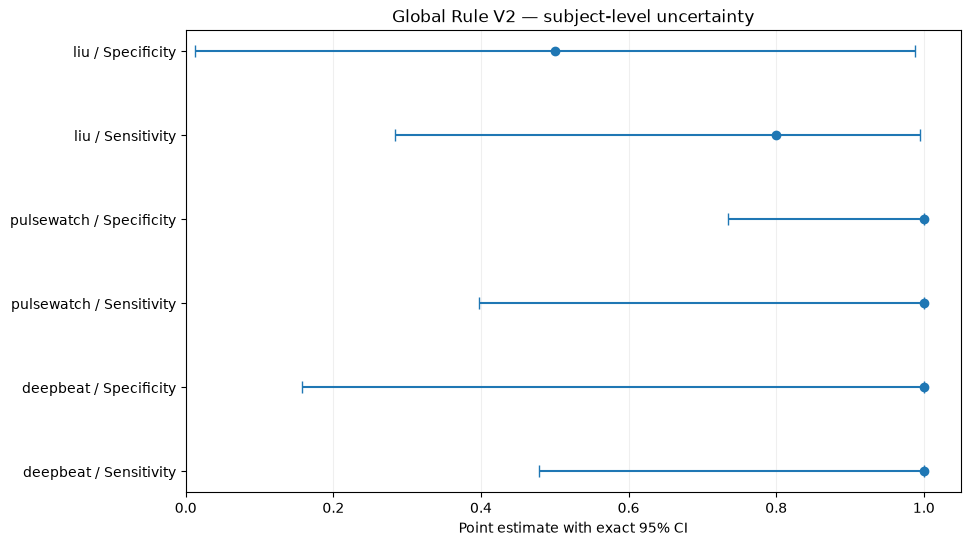

In [12]:
ci_file = ART / "global_rule_v2_exact_subject_ci.csv"

if ci_file.exists():
    ci = pd.read_csv(ci_file)
    display(ci)

    sens_spec = ci[ci["metric"].isin(["Sensitivity", "Specificity"])].copy()

    fig = plt.figure(figsize=(10, 6))
    y = np.arange(len(sens_spec))
    point = sens_spec["point_estimate"].to_numpy()
    low = sens_spec["exact_95_low"].to_numpy()
    high = sens_spec["exact_95_high"].to_numpy()

    plt.errorbar(
        point, y,
        xerr=np.vstack([point-low, high-point]),
        fmt="o",
        capsize=4
    )
    labels = sens_spec["dataset"] + " / " + sens_spec["metric"]
    plt.yticks(y, labels)
    plt.xlim(0, 1.05)
    plt.xlabel("Point estimate with exact 95% CI")
    plt.title("Global Rule V2 — subject-level uncertainty")
    plt.grid(axis="x", alpha=0.2)
    plt.show()
else:
    print("global_rule_v2_exact_subject_ci.csv chưa có.")

## 9. LODO domain generalization

,heldout_domain,evaluation_type,heldout_domain_used_for_training,heldout_domain_used_for_meta_training,group_definition,n_splits,train_rows,train_groups,eval_rows,eval_subjects,elapsed_seconds,AUROC,PR_AUC,Brier,TP,TN,FP,FN,sensitivity_at_0.5,specificity_at_0.5
0,DEEPBEAT,RETROSPECTIVE_LEAVE_ONE_DOMAIN_OUT,False,False,domain:subject_id,5,117634,140,25230,128,120.425235,0.838364,0.828943,0.189850,5546,14297,497,4890,0.531430,0.966405
1,PULSEWATCH,RETROSPECTIVE_LEAVE_ONE_DOMAIN_OUT,False,False,domain:subject_id,5,28334,174,156978,106,43.451791,0.987738,0.941706,0.056003,23156,124331,8606,885,0.963188,0.935263
2,LIU,RETROSPECTIVE_LEAVE_ONE_DOMAIN_OUT,False,False,domain:subject_id,5,133112,217,6280,45,153.929659,0.979742,0.959866,0.050021,2645,3250,318,67,0.975295,0.910874
3,MIMIC_PERFORM,RETROSPECTIVE_LEAVE_ONE_DOMAIN_OUT,False,False,domain:subject_id,5,133345,213,4130,35,159.029596,0.985598,0.986694,0.052994,2029,1803,85,213,0.904996,0.954979


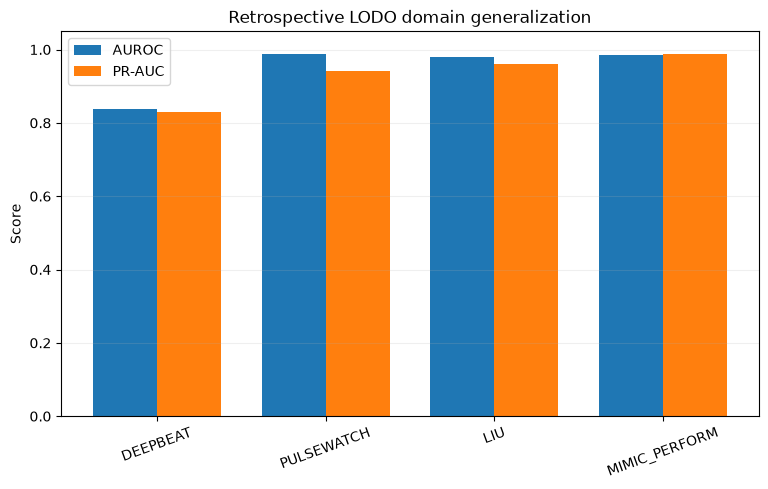

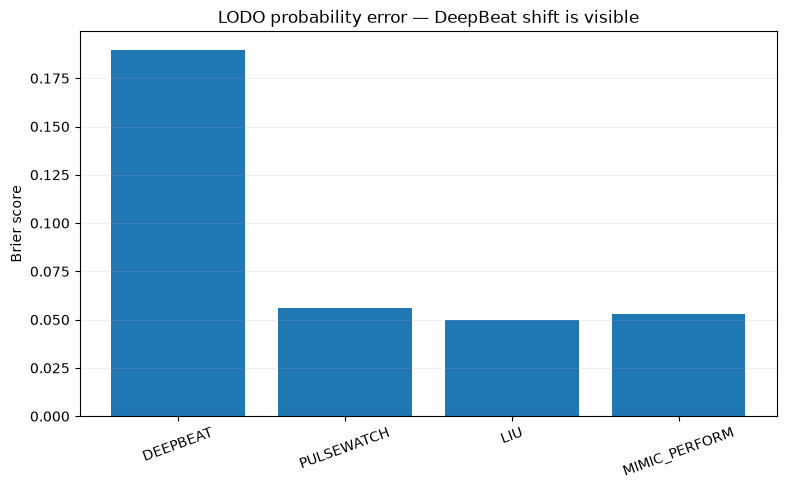

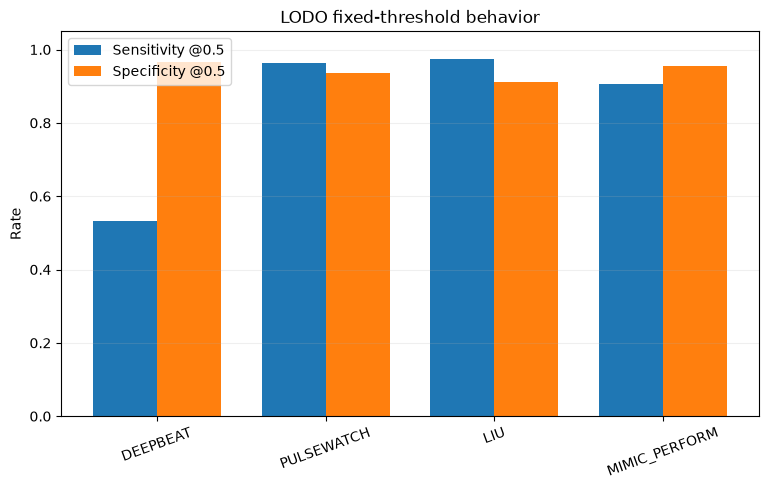

In [13]:
lodo_file = ART / "lodo_domain_generalization_summary.csv"

if lodo_file.exists():
    lodo = pd.read_csv(lodo_file)
    display(lodo)

    fig = plt.figure(figsize=(9, 5))
    x = np.arange(len(lodo))
    width = 0.38
    plt.bar(x-width/2, lodo["AUROC"], width, label="AUROC")
    plt.bar(x+width/2, lodo["PR_AUC"], width, label="PR-AUC")
    plt.xticks(x, lodo["heldout_domain"], rotation=20)
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title("Retrospective LODO domain generalization")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()

    fig = plt.figure(figsize=(9, 5))
    plt.bar(lodo["heldout_domain"], lodo["Brier"])
    plt.ylabel("Brier score")
    plt.title("LODO probability error — DeepBeat shift is visible")
    plt.xticks(rotation=20)
    plt.grid(axis="y", alpha=0.2)
    plt.show()

    fig = plt.figure(figsize=(9, 5))
    x = np.arange(len(lodo))
    plt.bar(x-width/2, lodo["sensitivity_at_0.5"], width, label="Sensitivity @0.5")
    plt.bar(x+width/2, lodo["specificity_at_0.5"], width, label="Specificity @0.5")
    plt.xticks(x, lodo["heldout_domain"], rotation=20)
    plt.ylim(0, 1.05)
    plt.ylabel("Rate")
    plt.title("LODO fixed-threshold behavior")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()
else:
    print("LODO summary chưa có.")

## 10. PPG_AC matched ablation

,variant,dataset,n_features,rows,subjects,AUROC,PR_AUC,Brier
0,13F_NO_PPG_AC,deepbeat,13,4026,13,0.778556,0.274198,0.147950
1,13F_NO_PPG_AC,pulsewatch,13,17679,16,0.986941,0.916362,0.032327
2,13F_NO_PPG_AC,liu,13,997,7,0.980612,0.662024,0.038411
3,14F_WITH_PPG_AC,deepbeat,14,4026,13,0.807113,0.426610,0.110630
4,14F_WITH_PPG_AC,pulsewatch,14,17679,16,0.990568,0.938564,0.028477
5,14F_WITH_PPG_AC,liu,14,997,7,0.981312,0.642643,0.042878


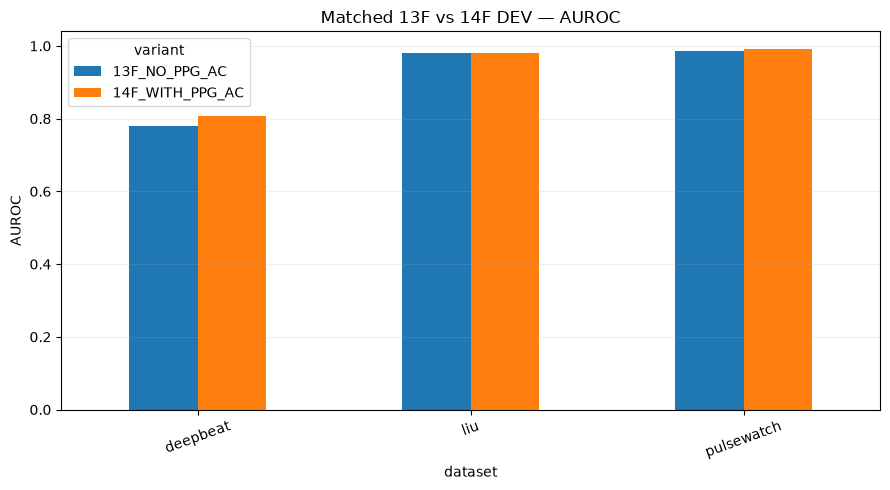

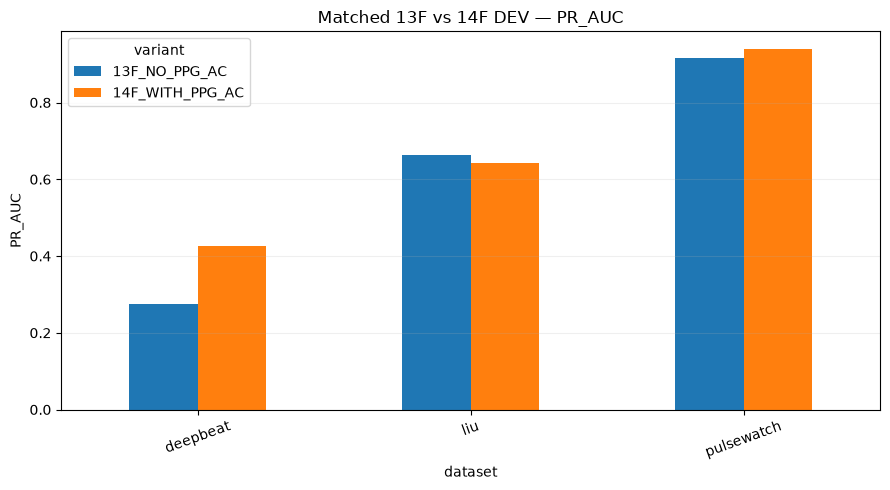

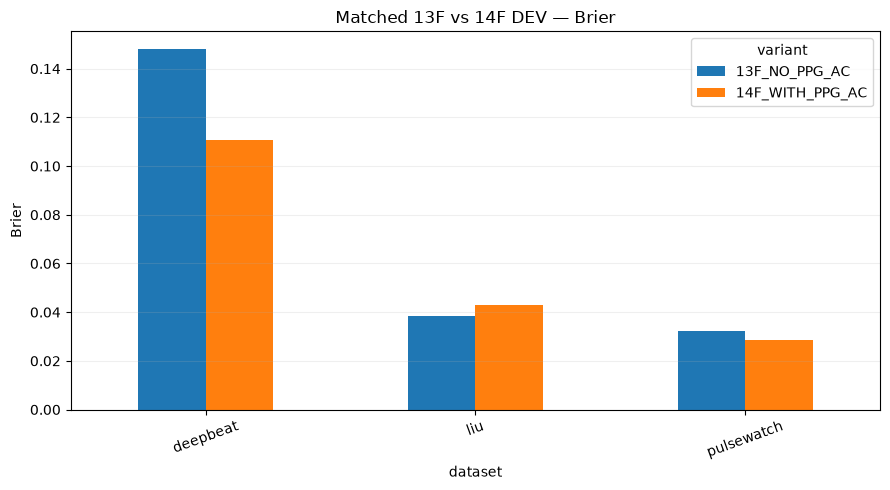

,variant,macro_AUROC,macro_PR_AUC,macro_Brier
0,13F_NO_PPG_AC,0.915370,0.617528,0.072896
1,14F_WITH_PPG_AC,0.926331,0.669272,0.060662


In [14]:
abl_file = ART / "ppg_ac_ablation_dev_summary.csv"
macro_file = ART / "ppg_ac_ablation_dev_macro.csv"

if abl_file.exists():
    abl = pd.read_csv(abl_file)
    display(abl)

    for metric in ["AUROC", "PR_AUC", "Brier"]:
        pivot = abl.pivot(index="dataset", columns="variant", values=metric)
        fig = plt.figure(figsize=(9, 5))
        pivot.plot(kind="bar", ax=plt.gca())
        plt.ylabel(metric)
        plt.title(f"Matched 13F vs 14F DEV — {metric}")
        plt.xticks(rotation=20)
        plt.grid(axis="y", alpha=0.2)
        plt.tight_layout()
        plt.show()

if macro_file.exists():
    macro = pd.read_csv(macro_file)
    display(macro)

## 11. PAC/PVC hard-negative challenge

,challenge,windows,mean_probability,median_probability,p90_probability,p95_probability,max_probability,mean_ensemble_std,FP_count_ge_0_5,FPR_ge_0_5,FP_count_ge_0_7,FPR_ge_0_7,FP_count_ge_0_8,FPR_ge_0_8,FP_count_ge_0_9,FPR_ge_0_9,FP_count_ge_0_95,FPR_ge_0_95
0,PULSEWATCH_PAC_PVC_TEST,264,0.082660,0.032231,0.159851,0.398831,0.937072,0.038658,12,0.045455,8,0.030303,4,0.015152,2,0.007576,0,0.00
1,PEAKDET_PAC_PVC,50,0.222393,0.062805,0.922211,0.941501,0.955827,0.074366,9,0.180000,9,0.180000,7,0.140000,6,0.120000,2,0.04


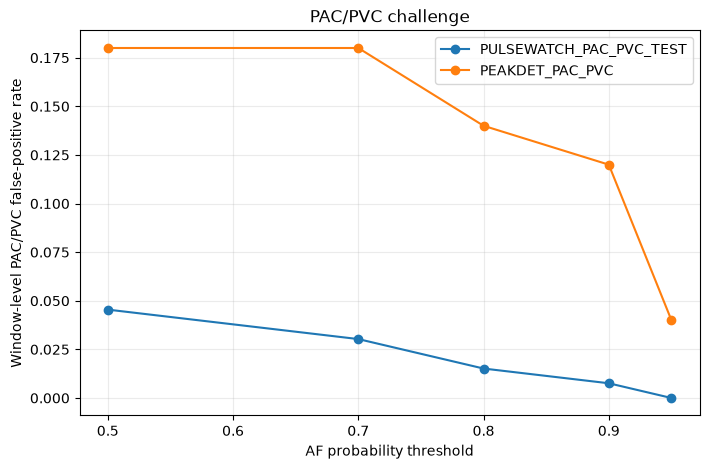

In [15]:
pac_file = ART / "pac_pvc_challenge_summary.csv"

if pac_file.exists():
    pac = pd.read_csv(pac_file)
    display(pac)

    thresholds = [0.5, 0.7, 0.8, 0.9, 0.95]
    fig = plt.figure(figsize=(8, 5))
    for _, r in pac.iterrows():
        vals = []
        for t in thresholds:
            col = f"FPR_ge_{str(t).replace('.', '_')}"
            vals.append(r[col])
        plt.plot(thresholds, vals, marker="o", label=r["challenge"])
    plt.xlabel("AF probability threshold")
    plt.ylabel("Window-level PAC/PVC false-positive rate")
    plt.title("PAC/PVC challenge")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
else:
    print("PAC/PVC summary chưa có.")

## 12. DeepBeat LODO forensic

,feature,TP_n,FN_n,TP_median,FN_median,FN_minus_TP_robust_shift,abs_shift,KS_statistic,KS_pvalue
0,PPG_AC,5546,4890,0.070384,0.181569,1.533817,1.533817,0.740280,0.000000e+00
1,CV,5546,4890,0.288514,0.175494,-0.969579,0.969579,0.502193,0.000000e+00
2,NN50,5546,4890,26.000000,19.000000,-0.933333,0.933333,0.515690,0.000000e+00
3,pNN50,5546,4890,87.804878,71.834936,-0.784323,0.784323,0.526469,0.000000e+00
4,RMSSD,5546,4890,310.242794,210.217651,-0.777781,0.777781,0.416029,8.942588e-322
5,SD1,5546,4890,223.004527,151.474413,-0.770122,0.770122,0.413139,1.170936e-321
6,SampEn,5546,4890,0.000000,0.961411,0.739764,0.739764,0.313061,1.616083e-225
7,Total_Power,5546,4890,29832.278248,8507.135580,-0.735012,0.735012,0.421143,4.100745e-322
8,SDNN,5546,4890,226.751499,152.132046,-0.718085,0.718085,0.407211,1.724289e-321
9,HF,5546,4890,17764.840027,5681.158881,-0.699150,0.699150,0.404495,1.981203e-321


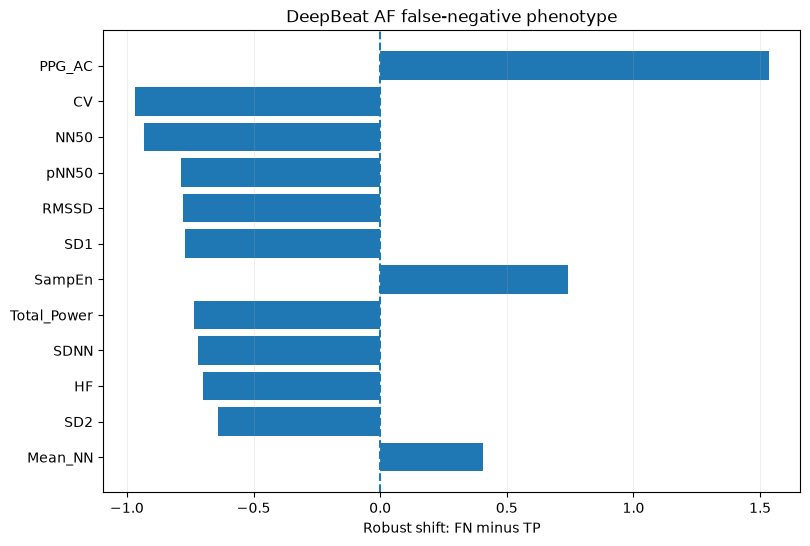

In [16]:
fn_file = ART / "deepbeat_lodo_fn_vs_tp_features.csv"

if fn_file.exists():
    fn = pd.read_csv(fn_file)
    display(fn.head(14))

    top = fn.sort_values("abs_shift", ascending=False).head(12).sort_values("abs_shift")

    fig = plt.figure(figsize=(9, 6))
    plt.barh(top["feature"], top["FN_minus_TP_robust_shift"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Robust shift: FN minus TP")
    plt.title("DeepBeat AF false-negative phenotype")
    plt.grid(axis="x", alpha=0.2)
    plt.show()
else:
    print("deepbeat_lodo_fn_vs_tp_features.csv chưa có.")

### DeepBeat PPG_AC quartiles

,feature,quartile,windows,feature_min,feature_median,feature_max,LODO_mean_probability,FULL_mean_probability,LODO_sensitivity_05,FULL_sensitivity_05
0,PPG_AC,Q1,280,0.042000,0.057124,0.061272,0.814270,0.889324,0.867857,0.950000
1,PPG_AC,Q2,280,0.061284,0.064761,0.068579,0.814119,0.884102,0.889286,0.942857
2,PPG_AC,Q3,280,0.068584,0.074902,0.093838,0.709429,0.828528,0.782143,0.889286
3,PPG_AC,Q4,280,0.094118,0.183963,0.251030,0.104703,0.258696,0.100000,0.167857


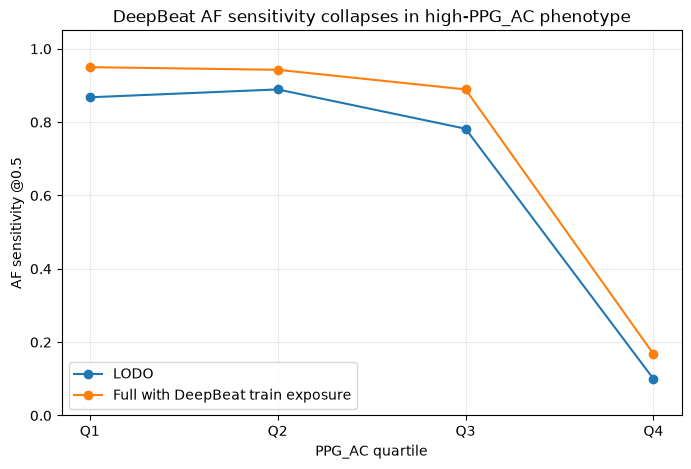

In [17]:
quart_file = ART / "deepbeat_af_phenotype_quartiles.csv"

if quart_file.exists():
    q = pd.read_csv(quart_file)
    q = q[q["feature"] == "PPG_AC"].copy()
    display(q)

    fig = plt.figure(figsize=(8, 5))
    plt.plot(q["quartile"], q["LODO_sensitivity_05"], marker="o", label="LODO")
    plt.plot(q["quartile"], q["FULL_sensitivity_05"], marker="o", label="Full with DeepBeat train exposure")
    plt.ylim(0, 1.05)
    plt.xlabel("PPG_AC quartile")
    plt.ylabel("AF sensitivity @0.5")
    plt.title("DeepBeat AF sensitivity collapses in high-PPG_AC phenotype")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
else:
    print("deepbeat_af_phenotype_quartiles.csv chưa có.")

## 13. DeepBeat domain exposure

,split,method,rows,subjects,AUROC,PR_AUC,Brier,TP,TN,FP,FN,sensitivity,specificity
0,dev,LODO_NO_DEEPBEAT,4026,13,0.730933,0.406819,0.097864,168,3407,110,341,0.330059,0.968723
1,dev,FULL_WITH_DEEPBEAT_TRAIN,4026,13,0.807879,0.433456,0.112268,226,3222,295,283,0.444008,0.916122
2,test,LODO_NO_DEEPBEAT,1363,7,0.983662,0.973827,0.044384,571,720,32,40,0.934534,0.957447
3,test,FULL_WITH_DEEPBEAT_TRAIN,1363,7,0.990391,0.988966,0.058315,600,645,107,11,0.981997,0.857713
4,DEV_TEST_COMBINED,LODO_NO_DEEPBEAT,5389,20,0.868257,0.771944,0.084338,739,4127,142,381,0.659821,0.966737
5,DEV_TEST_COMBINED,FULL_WITH_DEEPBEAT_TRAIN,5389,20,0.902725,0.804893,0.098622,826,3867,402,294,0.737500,0.905833


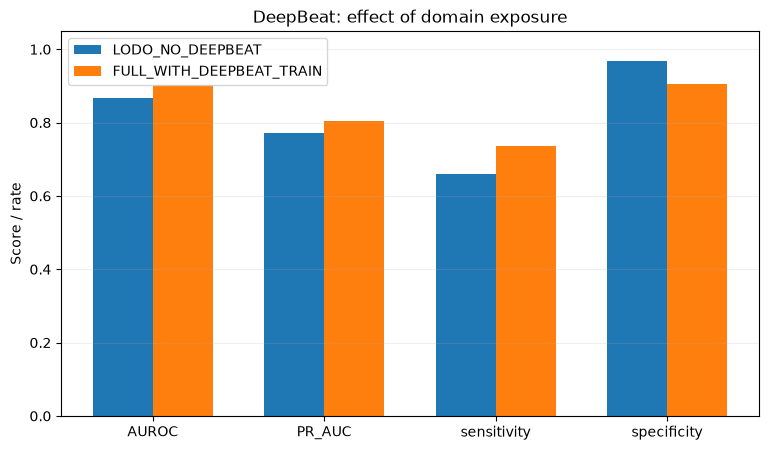

In [18]:
exp_file = ART / "deepbeat_domain_exposure_summary.csv"

if exp_file.exists():
    exp = pd.read_csv(exp_file)
    display(exp)

    combined = exp[exp["split"] == "DEV_TEST_COMBINED"].copy()
    if not combined.empty:
        metrics = ["AUROC", "PR_AUC", "sensitivity", "specificity"]
        x = np.arange(len(metrics))
        width = 0.35

        fig = plt.figure(figsize=(9, 5))
        methods = list(combined["method"])
        for i, (_, r) in enumerate(combined.iterrows()):
            vals = [r[m] for m in metrics]
            plt.bar(x + (i-0.5)*width, vals, width, label=r["method"])
        plt.xticks(x, metrics)
        plt.ylim(0, 1.05)
        plt.ylabel("Score / rate")
        plt.title("DeepBeat: effect of domain exposure")
        plt.legend()
        plt.grid(axis="y", alpha=0.2)
        plt.show()

## 14. DeepBeat LODO 13F vs 14F

,variant,split,rows,subjects,AUROC,PR_AUC,Brier,TP,TN,FP,FN,sensitivity,specificity
0,13F_NO_PPG_AC,ALL_DEEPBEAT,25230,128,0.813611,0.757496,0.203322,5808,13239,1555,4628,0.556535,0.894890
4,14F_WITH_PPG_AC,ALL_DEEPBEAT,25230,128,0.838364,0.828943,0.189850,5546,14297,497,4890,0.531430,0.966405


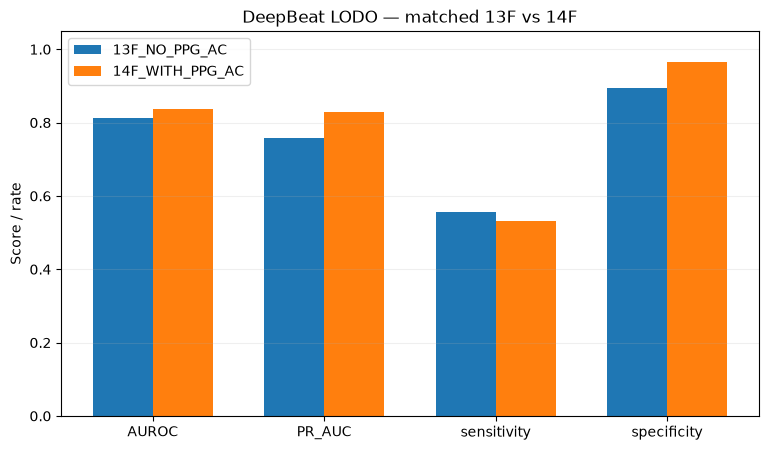

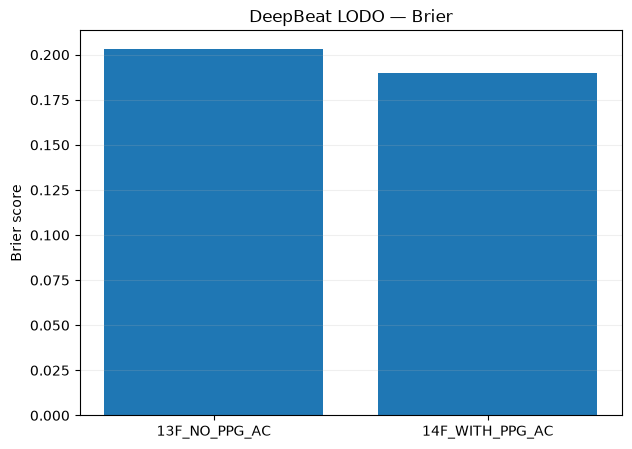

In [19]:
db_abl_file = ART / "deepbeat_lodo_ppg_ac_ablation_summary.csv"

if db_abl_file.exists():
    dbabl = pd.read_csv(db_abl_file)
    all_db = dbabl[dbabl["split"] == "ALL_DEEPBEAT"].copy()
    display(all_db)

    metrics = ["AUROC", "PR_AUC", "sensitivity", "specificity"]
    x = np.arange(len(metrics))
    width = 0.35

    fig = plt.figure(figsize=(9, 5))
    for i, (_, r) in enumerate(all_db.iterrows()):
        plt.bar(
            x + (i-0.5)*width,
            [r[m] for m in metrics],
            width,
            label=r["variant"]
        )
    plt.xticks(x, metrics)
    plt.ylim(0, 1.05)
    plt.ylabel("Score / rate")
    plt.title("DeepBeat LODO — matched 13F vs 14F")
    plt.legend()
    plt.grid(axis="y", alpha=0.2)
    plt.show()

    fig = plt.figure(figsize=(7, 5))
    plt.bar(all_db["variant"], all_db["Brier"])
    plt.ylabel("Brier score")
    plt.title("DeepBeat LODO — Brier")
    plt.grid(axis="y", alpha=0.2)
    plt.show()

## 15. Freeze hashes / provenance

In [20]:
sha_file = ART / "V6_RESEARCH_FREEZE_SHA256.csv"
prov_file = ART / "PROVENANCE_CORRECTIONS.md"

if sha_file.exists():
    sha = pd.read_csv(sha_file)
    display(sha)

if prov_file.exists():
    print(prov_file.read_text())

,file,bytes,sha256
0,models/multidomain/healthsense_af_v6c_stacking...,1876995235,e27370c51c8bbaf624abcbdabae40af5528d28bb2bd9e9...
1,experiments/08_v6_locked_protocol/artifacts/FR...,1077,e138116a22a03c882609b47f8a6a8a561a90883f188305...
2,experiments/08_v6_locked_protocol/artifacts/FR...,591,df2990026a64d27ead7478c4a4c2a34c17ee82c89d74b8...
3,experiments/08_v6_locked_protocol/artifacts/lo...,1179,c91a6571db882b1439e3277c7cbf8c33be0d0c75957220...
4,experiments/08_v6_locked_protocol/artifacts/pp...,611,8e006b2ea842b97bef081c0b10d10bb77e0b0d270c1d33...
5,experiments/08_v6_locked_protocol/artifacts/pp...,296,e1f4cc634488dc5362043e310cb9e18d0c426e2332833b...
6,experiments/08_v6_locked_protocol/artifacts/de...,1234,12e6428261c11ec4f82ac4e6594621084dfbd401498997...
7,experiments/08_v6_locked_protocol/artifacts/de...,517,e97ee018ff585483aa052f2e5617446b00db90adc6f404...
8,experiments/08_v6_locked_protocol/artifacts/pa...,672,b4bbaed9882248704f851edd9e8cc9fba4106170bdbc7f...
9,experiments/08_v6_locked_protocol/artifacts/gl...,1551,4d5ce0213870b8fcb84aae2fbdb2e4a112066fb396510c...


# Provenance corrections

## MIMIC

Any previous V6 artifact that labels the existing 4,130-window
MIMIC dataset as `MIMIC-III-Ext-PPG` must not be reported under
that name.

Correct source:

`MIMIC PERform AF`

MIMIC-III-Ext-PPG has not yet been used.

## Test terminology

The existing DeepBeat, PulseWatch and Liu test results should be
described as:

`reused subject-held-out benchmarks`

They are subject-disjoint from training, but the datasets and test
results have been inspected during model development.

## LODO terminology

The leave-one-domain-out experiments should be described as:

`retrospective leave-one-domain-out domain-generalization analysis`

They are not pristine external validation because these datasets
were already known during the project.

## Subject alert rule

V6 Global Rule V2 is an exploratory frozen candidate.

It must not be described as a confirmed deployment threshold before
evaluation on a future untouched dataset.

## Calibration

Raw `meta_probability` 

## 16. Kết luận notebook V6

Khi duyệt để push GitHub, notebook này nên kể đúng câu chuyện:

1. Window classifier V6C mạnh trên reused subject-held-out benchmarks.
2. Temporal V1 cho thấy ANY-positive aggregation là sai.
3. V2 dùng verified streams và global persistence rule.
4. Calibration chưa đủ nhất quán để promote.
5. Confidence interval phải phản ánh small-n subject test.
6. LODO cho thấy DeepBeat domain shift rất rõ.
7. PPG_AC vẫn nên giữ theo matched ablation.
8. PAC/PVC đã cải thiện nhưng PeakDet vẫn là hard negative.
9. DeepBeat high-PPG_AC AF phenotype là failure mode quan trọng.
10. Vì benchmarks đã được inspect nhiều, **dừng tuning** và giữ MIMIC-III-Ext-PPG/TriggersAF cho sealed validation.

## 17. GitHub export suggestion

In [21]:
NOTEBOOK_TARGET = REPO / "notebooks"
print("Suggested repo folder:", NOTEBOOK_TARGET)
print("Suggested files:")
print(" - notebooks/HealthSense_V5_Visual_Review.ipynb")
print(" - notebooks/HealthSense_V6_Research_Freeze_Visual_Review.ipynb")
print(" - notebooks/README.md")
print("\nKhuyến nghị Clear Outputs trước khi commit nếu repo muốn notebook nhẹ,")
print("hoặc giữ outputs nếu muốn GitHub render kết quả/figures ngay.")

Suggested repo folder: /home/phuc/Documents/HealthSense_rungtamnhi/notebooks
Suggested files:
 - notebooks/HealthSense_V5_Visual_Review.ipynb
 - notebooks/HealthSense_V6_Research_Freeze_Visual_Review.ipynb
 - notebooks/README.md

Khuyến nghị Clear Outputs trước khi commit nếu repo muốn notebook nhẹ,
hoặc giữ outputs nếu muốn GitHub render kết quả/figures ngay.
